 (pg.601~625)

### 05. 콘텐츠 기반 필터링 실습 - TMDB 5000 영화 데이터 세트

**콘텐츠 기반 필터링**

사용자가 특정 영화를 감상하고 그 영화를 좋아했다면 그 영화와 비슷한 특성/속성, 구성 요소 등을 가진 다른 영화를 추천하는 것이다.

영화(상품/서비스) 간의 유사성을 판단하는 기준이 영화를 구성하는 다양한 콘텐츠를 기반으로 하는 방식이다.

- 데이터 로딩 및 가공

In [1]:
import pandas as pd
import numpy as np
import warnings; warnings.filterwarnings('ignore')

movies = pd.read_csv('/content/drive/MyDrive/data/tmdb_5000_movies.csv')
print(movies.shape)
movies.head(1)

(4803, 20)


,budget,genres,homepage,id,keywords,original_language,original_title,overview,popularity,production_companies,production_countries,release_date,revenue,runtime,spoken_languages,status,tagline,title,vote_average,vote_count
0,237000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.avatarmovie.com/,19995,"[{""id"": 1463, ""name"": ""culture clash""}, {""id"":...",en,Avatar,"In the 22nd century, a paraplegic Marine is di...",150.437577,"[{""name"": ""Ingenious Film Partners"", ""id"": 289...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2009-12-10,2787965087,162.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}, {""iso...",Released,Enter the World of Pandora.,Avatar,7.2,11800


4803개의 레코드와 20개의 피처로 구성되어 있음

영화 제목, 개요, 인기도, 평점, 투표수, 예산, 키워드 등 영화에 대한 다양한 메타 정보를 가지고 있음

In [2]:
movies_df = movies[['id', 'title','genres','vote_average','vote_count','popularity','keywords','overview']]

처리할 때 주의해야 할 칼럼이 있다.

genres와 keywords등과 같은 칼럼을 보면 파이썬 리스트 내부에 여러 개의 딕셔너리가 있는 형태의 문자열로 표기되어 있다. 이는 한꺼번에 여러 개의 값을 표현하기 위한 표기 방식이다.

여러 가지 장르로 구성될 수 있기 때문

In [3]:
pd.set_option('max_colwidth', 100)
movies_df[['genres', 'keywords']][:1]

,genres,keywords
0,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""name"": ""Adventure""}, {""id"": 14, ""name"": ""Fantasy""}, {...","[{""id"": 1463, ""name"": ""culture clash""}, {""id"": 2964, ""name"": ""future""}, {""id"": 3386, ""name"": ""sp..."


In [4]:
from ast import literal_eval
movies_df['genres'] = movies_df['genres'].apply(literal_eval)
movies_df['keywords'] = movies_df['keywords'].apply(literal_eval)

이제 genres칼럼은 문자열이 아니라 실제 리스트 내부에 여러 장르 딕셔너리로 구성된 객체를 가진다. genres칼럼에서 장르명만 리스트 객체로 추출한다. genres칼럼에서 'name'키에 해당하는 값을 추출하기 위해 apply lambda 식을 이용한다.

In [5]:
movies_df['genres']=movies_df['genres'].apply(lambda x: [y['name'] for y in x])
movies_df['keywords']=movies_df['keywords'].apply(lambda x: [y['name'] for y in x])
movies_df[['genres','keywords']][:1]

,genres,keywords
0,"[Action, Adventure, Fantasy, Science Fiction]","[culture clash, future, space war, space colony, society, space travel, futuristic, romance, spa..."


- 장르 콘텐츠 유사도 측정

genres를 문자열로 변경한 뒤 이를 CountVectorizer로 피처 벡터화한 행렬 데이터 값을 코사인 유사도로 비교하는 것이다.

1. 문자열로 변환된 genres 칼럼을 Count 기반으로 피처 벡터화 변환
2. genres 문자열을 피처 벡터화 행렬로 변환한 데이터 세트를 코사인 유사도를 통해 비교. 이를 위해 데이터 세트의 레코드별로 타 레코드와 장르에서 코사인 유사도 값을 가지는 객체를 생성한다.
3. 장르 유사도가 높은 영화 중에 평점이 높은 순으로 영화를 추천한다.

In [6]:
from sklearn.feature_extraction.text import CountVectorizer

# CountVectorizer를 적용하기 위해 공백문자로 word 단위가 구분되는 문자열로 변환
movies_df['genres_literal']=movies_df['genres'].apply(lambda x: (' ').join(x))
count_vect = CountVectorizer(min_df=0.0, ngram_range=(1,2))
genre_mat = count_vect.fit_transform(movies_df['genres_literal'])
print(genre_mat.shape)

(4803, 276)


CountVectorizer로 변환해 4803개의 레코드와 276개의 개별 단어 피처로 구성된 피처 벡터 행렬이 만들어졌다.

cosine_similarity()함수를 이용해 코사인 유사도를 계산한다.

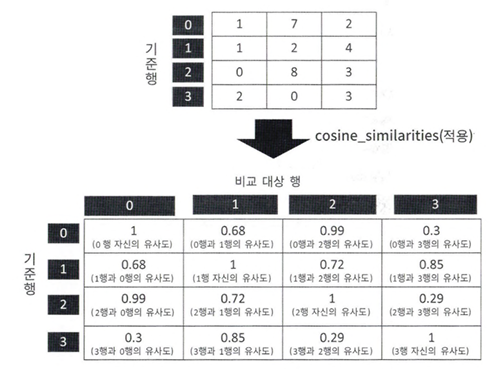

In [7]:
from sklearn.metrics.pairwise import cosine_similarity

genre_sim = cosine_similarity(genre_mat, genre_mat)
print(genre_sim.shape)
print(genre_sim[:2])

(4803, 4803)
[[1.         0.59628479 0.4472136  ... 0.         0.         0.        ]
 [0.59628479 1.         0.4        ... 0.         0.         0.        ]]


movies_df를 장르 기준으로 콘텐츠 기반 필터링을 수행하려면 movies_df의 개별 레코드에 대해서 가장 장르 유사도가 높은 순으로 다른 레코드를 추출해야 하는데, 이를 위해 앞에서 생성한 genre_sim객체를 이용한다.

genre_sim 객체의 기준 행별로 비교 대상이 되는 행의 유사도 값이 높은 순으로 정렬된 행렬의 위치 인덱스 값을 추출하면 된다. 값이 높은 순으로 정렬된 비교 대상 행의 유사도 값이 아니라 비교 대상 행의 위치 인덱스임에 주의해야 한다.

argsort()함수를 이용한다.

In [8]:
genre_sim_sorted_ind = genre_sim.argsort()[:,::-1]
print(genre_sim_sorted_ind[:1])

[[   0   46 3494 ... 3331 3333 2031]]


0번의 레코드의 경우 자신인 0번을 제외하면 46번 레코드가 가장 유사도가 높고, 그 다음이 3494번 레코드이며, 가장 유사도가 낮은 레코드는 2031번 레코드이다.

- 장르 콘텐츠 필터링을 이용한 영화 추천

In [9]:
def find_sim_movie(df, sorted_ind, title_name, top_n=10):
  #인자로 입력된 movies_df DataFrame에서 'title'칼럼이 입력된 title_name값인 DataFrame 추출
  title_movie = df[df['title']==title_name]

  #title_name을 가진 DataFrame의 index 객체를 ndarray로 반환하고
  #sorted_ind 인자로 입력된 genre_sim_sorted_ind 객체에서 유사도 순으로 top_n개의 index 추출
  title_index = title_movie.index.values
  similar_indexes = sorted_ind[title_index,:(top_n)]

  #추출된 top_n index 출력, top_n index는 2차원 데이터임.
  #dataframe에서 index로 사용하기 위해서 1차원 array로 변경
  print(similar_indexes)
  similar_indexes = similar_indexes.reshape(-1)

  return df.iloc[similar_indexes]

In [10]:
similar_movies = find_sim_movie(movies_df, genre_sim_sorted_ind, 'The Godfather', 10)
similar_movies[['title', 'vote_average']]

[[1881 3378 3866 1370 1464  588 3887 3594 2839  892]]


,title,vote_average
1881,The Shawshank Redemption,8.5
3378,Auto Focus,6.1
3866,City of God,8.1
1370,21,6.5
1464,Black Water Transit,0.0
588,Wall Street: Money Never Sleeps,5.8
3887,Trainspotting,7.8
3594,Spring Breakers,5.0
2839,Rounders,6.9
892,Casino,7.8


좀 더 많은 후보군을 선정한 뒤에 영화의 평점에 따라 필터링해서 최종 추천하는 방식으로 변경한다. 영화의 평점 정보인 vote_average값을 이용한다. **주의할점**은 0부터 10까지의 점수로 돼 있는데, 여러 관객이 평가한 평점을 평균한 것이다. 그런데 **1명, 2명의 소수의 관객이 특정 영화에 만점이나 매우 높은 평점을 부여해 왜곡된 데이터를 가지고 있다.** 이를 확인하기 위해 sort_values()를 이용해 평점 오름차순으로 movies_df를 정렬해서 10개만 출력한다.

In [11]:
movies_df[['title', 'vote_average','vote_count']].sort_values('vote_average', ascending=False)[:10]

,title,vote_average,vote_count
4662,Little Big Top,10.0,1
3519,Stiff Upper Lips,10.0,1
4045,"Dancer, Texas Pop. 81",10.0,1
4247,Me You and Five Bucks,10.0,2
3992,Sardaarji,9.5,2
2386,One Man's Hero,9.3,2
1881,The Shawshank Redemption,8.5,8205
2970,There Goes My Baby,8.5,2
3337,The Godfather,8.4,5893
2796,The Prisoner of Zenda,8.4,11


평가 횟수가 매우 작은 왜곡된 평점 데이터를 회피할 수 있도록 평점에 평가 횟수를 반영할 수 있는 새로운 평가 방식이 필요하다.

$$가중 평점(Weighted Rating) = (v/(v+m)) * R + (m/(v+m)) * C$$

- v: 개별 영화에 평점을 투표한 횟수
- m: 평점을 부여하기 위한 최소 투표 횟수
- R: 개별 영화에 대한 평균 평점
- C: 전체 영화에 대한 평균 평점

In [12]:
C = movies_df['vote_average'].mean()
m = movies_df['vote_count'].quantile(0.6)
print('C:', round(C,3),'m:', round(m,3))

C: 6.092 m: 370.2


기존 평점을 새로운 가중 평점으로 변경하는 함수를 생성하고 이를 이용해 새로운 평점 정보인 'vote_weighted'값을 만든다.

In [13]:
percentile = 0.6
m = movies_df['vote_count'].quantile(percentile)
C = movies_df['vote_average'].mean()

def weighted_vote_average(record):
  v = record['vote_count']
  R = record['vote_average']

  return ((v/(v+m))*R)+((m/(m+v))*C)

movies_df['weighted_vote'] = movies_df.apply(weighted_vote_average, axis=1)

새롭게 부여된 weight_vote평점이 높은 순으로 상위 10개의 영화를 추출한다.

In [14]:
movies_df[['title','vote_average','weighted_vote','vote_count']].sort_values(
    'weighted_vote', ascending=False)[:10]

,title,vote_average,weighted_vote,vote_count
1881,The Shawshank Redemption,8.5,8.396052,8205
3337,The Godfather,8.4,8.263591,5893
662,Fight Club,8.3,8.216455,9413
3232,Pulp Fiction,8.3,8.207102,8428
65,The Dark Knight,8.2,8.136930,12002
1818,Schindler's List,8.3,8.126069,4329
3865,Whiplash,8.3,8.123248,4254
809,Forrest Gump,8.2,8.105954,7927
2294,Spirited Away,8.3,8.105867,3840
2731,The Godfather: Part II,8.3,8.079586,3338


장르 유사성이 높은 영화를 top_n의 2배수만큼 후보군으로 선정한 뒤에 weighted_vote칼럼 값이 순으로 top_n만큼 추출하는 방식으로 find_sim_movie()함수를 변경한다. 변경된 find_sim_movie()를 이용해 다시 한번 유사한 영화를 **콘텐츠 기반 필터링**방식으로 추천

In [15]:
def find_sim_movie(df, sorted_ind, title_name, top_n=10):
  title_movie = df[df['title']==title_name]
  title_index = title_movie.index.values

  #top_n의 2배에 해당하는 장르 유사성이 높은 인덱스 추출
  similar_indexes = sorted_ind[title_index, :(top_n*2)]
  similar_indexes = similar_indexes.reshape(-1)
  #기준 영화 인덱스는 제외
  similar_indexes = similar_indexes[similar_indexes!=title_index]

  #top_n의 2배에 해당하는 후보군에서 weighted_vote가 높은 순으로 top_n만큼 추출
  return df.iloc[similar_indexes].sort_values('weighted_vote', ascending=False)[:top_n]

similar_movies = find_sim_movie(movies_df, genre_sim_sorted_ind, 'The Godfather', 10)
similar_movies[['title','vote_average','weighted_vote']]

,title,vote_average,weighted_vote
1881,The Shawshank Redemption,8.5,8.396052
2731,The Godfather: Part II,8.3,8.079586
1847,GoodFellas,8.2,7.976937
3866,City of God,8.1,7.759693
1663,Once Upon a Time in America,8.2,7.657811
3887,Trainspotting,7.8,7.591009
883,Catch Me If You Can,7.7,7.557097
892,Casino,7.8,7.423040
4041,This Is England,7.4,6.739664
1149,American Hustle,6.8,6.717525


###06. 아이템 기반 최근접 이웃 협업 필터링 실습

In [16]:
import pandas as pd
import numpy as np

movies = pd.read_csv('/content/drive/MyDrive/data/movies.csv')
ratings = pd.read_csv('/content/drive/MyDrive/data/ratings.csv')
print(movies.shape)
print(ratings.shape)

(9742, 3)
(100836, 4)


```pivot_table()```함수는 로우 레벨의 값을 칼럼으로 변경하는 데 효과적이다. pivot_table()에 인자로 columns='movieId'와 같이 부여하면 movieId칼럼의 모든 값이 새로운 칼럼 이름으로 변환된다.

In [17]:
ratings = ratings[['userId','movieId','rating']]
ratings_matrix = ratings.pivot_table('rating',index='userId', columns='movieId')
ratings_matrix.head(3)

movieId,1,2,3,4,5,6,7,8,9,10,...,193565,193567,193571,193573,193579,193581,193583,193585,193587,193609
userId,,,,,,,,,,,,,,,,,,,,,
1,4.0,NaN,4.0,NaN,NaN,4.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


NaN값이 많은 이유는 사용자가 평점을 매기지 않은 영화가 칼럼으로 변환되면서 NaN으로 값이 할당되었기 때문이다.

가독성을 높이기 위해 칼럼명은 movieId가 아닌 영화명 title로 변경한다.

영화면은 ratings에 존재하지 않고 movies 데이터 세트에 존재한다. ratings와 movies를 조인해 title칼럼을 가져온 뒤에 pivot_table()의 인자로 columns에 movieId가 아닌 title을 입력해 title로 피벗한다.

In [18]:
# title 칼럼을 얻기 위해 movies와 조인
rating_movies = pd.merge(ratings, movies, on='movieId')

#columns='title'로 title칼럼으로 피벗 수행
ratings_matrix = rating_movies.pivot_table('rating',index='userId', columns='title')

#NaN값을 모두 0으로 변환
ratings_matrix = ratings_matrix.fillna(0)
ratings_matrix.head(3)

title,'71 (2014),'Hellboy': The Seeds of Creation (2004),'Round Midnight (1986),'Salem's Lot (2004),'Til There Was You (1997),'Tis the Season for Love (2015),"'burbs, The (1989)",'night Mother (1986),(500) Days of Summer (2009),*batteries not included (1987),...,Zulu (2013),[REC] (2007),[REC]² (2009),[REC]³ 3 Génesis (2012),anohana: The Flower We Saw That Day - The Movie (2013),eXistenZ (1999),xXx (2002),xXx: State of the Union (2005),¡Three Amigos! (1986),À nous la liberté (Freedom for Us) (1931)
userId,,,,,,,,,,,,,,,,,,,,,
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


- 영화 간 유사도 산출

영화간의 유사도는 코사인 유사도를 기반으로 하고, 사이킷런의 cosine_similarity()를 이용해 영화 간 유사도를 측정한다.

영화를 기준으로 cosine_similarity()를 적용하려면 현재의 ratings_matrix가 행 기준이 영화가 되고 열 기준이 사용자가 되어야 한다.

In [19]:
ratings_matrix_T = ratings_matrix.transpose()
ratings_matrix_T.head(3)

userId,1,2,3,4,5,6,7,8,9,10,...,601,602,603,604,605,606,607,608,609,610
title,,,,,,,,,,,,,,,,,,,,,
'71 (2014),0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.0
'Hellboy': The Seeds of Creation (2004),0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
'Round Midnight (1986),0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [20]:
from sklearn.metrics.pairwise import cosine_similarity

item_sim = cosine_similarity(ratings_matrix_T, ratings_matrix_T)

#cosine_similarity()로 반환된 넘파이 행렬을 영화명을 매핑해 DataFrame으로 변환
item_sim_df = pd.DataFrame(data=item_sim, index=ratings_matrix.columns, columns=ratings_matrix.columns)

print(item_sim_df.shape)
item_sim_df.head(3)

(9719, 9719)


title,'71 (2014),'Hellboy': The Seeds of Creation (2004),'Round Midnight (1986),'Salem's Lot (2004),'Til There Was You (1997),'Tis the Season for Love (2015),"'burbs, The (1989)",'night Mother (1986),(500) Days of Summer (2009),*batteries not included (1987),...,Zulu (2013),[REC] (2007),[REC]² (2009),[REC]³ 3 Génesis (2012),anohana: The Flower We Saw That Day - The Movie (2013),eXistenZ (1999),xXx (2002),xXx: State of the Union (2005),¡Three Amigos! (1986),À nous la liberté (Freedom for Us) (1931)
title,,,,,,,,,,,,,,,,,,,,,
'71 (2014),1.0,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.0,0.141653,0.0,...,0.0,0.342055,0.543305,0.707107,0.0,0.0,0.139431,0.327327,0.0,0.0
'Hellboy': The Seeds of Creation (2004),0.0,1.000000,0.707107,0.0,0.0,0.0,0.000000,0.0,0.000000,0.0,...,0.0,0.000000,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.0,0.0
'Round Midnight (1986),0.0,0.707107,1.000000,0.0,0.0,0.0,0.176777,0.0,0.000000,0.0,...,0.0,0.000000,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.0,0.0


In [21]:
item_sim_df["Godfather, The (1972)"].sort_values(ascending=False)[:6]

,"Godfather, The (1972)"
title,
"Godfather, The (1972)",1.000000
"Godfather: Part II, The (1974)",0.821773
Goodfellas (1990),0.664841
One Flew Over the Cuckoo's Nest (1975),0.620536
Star Wars: Episode IV - A New Hope (1977),0.595317
Fargo (1996),0.588614


장르가 완전히 다른 영화도 유사도가 매우 높게 나타난 경우가 있다.

In [22]:
item_sim_df["Inception (2010)"].sort_values(ascending=False)[1:6]

,Inception (2010)
title,
"Dark Knight, The (2008)",0.727263
Inglourious Basterds (2009),0.646103
Shutter Island (2010),0.617736
"Dark Knight Rises, The (2012)",0.617504
Fight Club (1999),0.615417


- 아이템 기반 최근접 이웃 협업 필터링으로 개인화된 영화 추천

앞의 예제는 개인적인 취향은 반영하지 않고 영화 간의 유사도만을 가지고 추천한 것이다.

이번에는 영화 유사도 데이터를 이용해 최근접 이웃 협업 필터링으로 개인에게 최적화된 영화 추천을 구현해보겠습니다.

아이템 기반의 협업 필터링에서 개인화된 예측 평점은 다음 식으로 구할 수 있다.

$$\hat{R}_{u,i} = \frac{\sum^{N} (S_{i,N} * R_{u,N})}{\sum^{N} (|S_{i,N}|)}$$

여기서 N값은 아이템의 최근접 이웃 범위 계수를 의미한다.

이는 특정 아이템과 유사도가 가장 높은 Top-N개의 다른 아이템을 추출하는 데 사용된다.

앞 예제에서 생성된 영화 간의 유사도를 가지는 DataFrame인 item_sim_df와 사용자-영화 평점 DataFrame인 ratings_matrix변수를 계속 활용해 사용자별로 최적화된 평점 스코어를 예측하는 함수를 만든다.

In [23]:
def predict_rating(ratings_arr, item_sim_arr):
  ratings_pred = ratings_arr.dot(item_sim_arr)/np.array([np.abs(item_sim_arr).sum(axis=1)])
  return ratings_pred

In [24]:
ratings_pred = predict_rating(ratings_matrix.values, item_sim_df.values)
ratings_pred_matrix = pd.DataFrame(data=ratings_pred, index=ratings_matrix.index, columns=ratings_matrix.columns)
ratings_pred_matrix.head(3)

title,'71 (2014),'Hellboy': The Seeds of Creation (2004),'Round Midnight (1986),'Salem's Lot (2004),'Til There Was You (1997),'Tis the Season for Love (2015),"'burbs, The (1989)",'night Mother (1986),(500) Days of Summer (2009),*batteries not included (1987),...,Zulu (2013),[REC] (2007),[REC]² (2009),[REC]³ 3 Génesis (2012),anohana: The Flower We Saw That Day - The Movie (2013),eXistenZ (1999),xXx (2002),xXx: State of the Union (2005),¡Three Amigos! (1986),À nous la liberté (Freedom for Us) (1931)
userId,,,,,,,,,,,,,,,,,,,,,
1,0.070345,0.577855,0.321696,0.227055,0.206958,0.194615,0.249883,0.102542,0.157084,0.178197,...,0.113608,0.181738,0.133962,0.128574,0.006179,0.212070,0.192921,0.136024,0.292955,0.720347
2,0.018260,0.042744,0.018861,0.000000,0.000000,0.035995,0.013413,0.002314,0.032213,0.014863,...,0.015640,0.020855,0.020119,0.015745,0.049983,0.014876,0.021616,0.024528,0.017563,0.000000
3,0.011884,0.030279,0.064437,0.003762,0.003749,0.002722,0.014625,0.002085,0.005666,0.006272,...,0.006923,0.011665,0.011800,0.012225,0.000000,0.008194,0.007017,0.009229,0.010420,0.084501


예측 평점이 사용자별 영화의 실제 평점과 영화의 코사인 유사도를 내적한 값이기 때문에 기존에 영화를 관람하지 않아 0에 해당했던 실제 영화 평점이 예측에서는 값이 부여되는 경우가 많이 발생한다.

예측 평점이 실제 평점에 비해 작을 수 있다. 이는 내적 결과를 코사인 유사도 벡터 합으로 나누었기 때문에 생기는 현상이다.


예측 평가 지표는 MSE를 적용한다. MSE를 측정할 때 유의할 점이 있다. 사용자가 영화의 평점을 주지 않은 경우 앞에서는 평점 0을 부과했다. 하지만 앞에서 개인화된 예측 점수는 평점을 주지 않은 영화에 대해서도 아이템 유사도에 기반해 평점을 예측했다.

In [26]:
from sklearn.metrics import mean_squared_error

#사용자가 평점을 부여한 영화에 대해서만 예측 성능 평가 MSE를 구함
def get_mse(pred, actual):
  #평점이 있는 실제 영화만 추출
  pred = pred[actual.nonzero()].flatten()
  actual = actual[actual.nonzero()].flatten()
  return mean_squared_error(pred, actual)

print('아이템 기반 모든 최근접 이웃 MSE:', get_mse(ratings_pred, ratings_matrix.values))

아이템 기반 모든 최근접 이웃 MSE: 9.895354759094706


 실제 값과 예측값은 서로 스케일이 다르기 때문에 MSE가 클 수도 있다.

 중요한 것은 MSE를 감소시키는 방향으로 개선하는 것이다.

In [27]:
def predict_rating_topsim(ratings_arr, item_sim_arr, n=20):
  #사용자-아이템 평점 행렬 크기만큼 0으로 채운 예측 행렬 초기화
  pred = np.zeros(ratings_arr.shape)

  #사용자-아이템 펴엄 행렬의 열 크기만큼 루프 수행
  for col in range(ratings_arr.shape[1]):
    #유사도 행렬에서 유사도가 큰 순으로 n개 데이터 행렬의 인덱스 반환
    top_n_items = [np.argsort(item_sim_arr[:,col])[:-n-1:-1]]
    #개인화된 예측 평점을 계산
    for row in range(ratings_arr.shape[0]):
      pred[row, col] = item_sim_arr[col,:][top_n_items].dot(ratings_arr[row,:][top_n_items].T)
      pred[row, col]/=np.sum(np.abs(item_sim_arr[col,:][top_n_items]))


  return pred

In [29]:
ratings_pred = predict_rating_topsim(ratings_matrix.values, item_sim_df.values, n=20)
print('아이템 기반 최근접 Top-20 이웃 MSE:', get_mse(ratings_pred, ratings_matrix.values))

#계산된 예측 평점 데이터는 DataFrame으로 재생성
ratings_pred_matrix = pd.DataFrame(data=ratings_pred, index=ratings_matrix.index, columns=ratings_matrix.columns)

아이템 기반 최근접 Top-20 이웃 MSE: 3.694409449382562


 userid = 9인 사용자에 대해 영화를 추천

  먼저 9번 userid 사용자가 어떤 영화를 좋아하는지 확인해 보겠습니다. 사용자가 평점을 준 영화를 평점이 높은 순으로 나열한다.

In [30]:
user_rating_id = ratings_matrix.loc[9,:]
user_rating_id[user_rating_id>0].sort_values(ascending=False)[:10]

,9
title,
Adaptation (2002),5.0
Austin Powers in Goldmember (2002),5.0
Back to the Future (1985),5.0
Citizen Kane (1941),5.0
"Lord of the Rings: The Fellowship of the Ring, The (2001)",5.0
"Lord of the Rings: The Two Towers, The (2002)",5.0
"Producers, The (1968)",5.0
Raiders of the Lost Ark (Indiana Jones and the Raiders of the Lost Ark) (1981),5.0
Elling (2001),4.0


사용자가 이미 평점을 준 영화를 제외하고 추천할 수 있도록 평점을 주지 않은 영화를 리스트 객체로 반환하는 함수```get_unseen_movies()```를 생성

In [33]:
def get_unseen_movies(ratings_matrix, userId):
  #userId로 입력받은 사용자의 모든 영화 정보를 추출해 Series로 반환

  #반환된 user_rating은 영화명을 인덱스로 가지는 Series 객체
  user_rating = ratings_matrix.loc[userId,:]

  #user_Rating이 0보다 크면 기존에 관람한 영화. 대상 인덱스를 추출해 list객체로 만든다.
  already_seen = user_rating[user_rating>0].index.tolist()

  #모든 영화명을 list객체로 만든다
  movies_list = ratings_matrix.columns.tolist()

  #list comprehension으로 already_seen에 해당하는 영화는 movies_list에서 제외
  unseen_list = [movie for movie in movies_list if movie not in already_seen]

  return unseen_list

In [35]:
def recomm_movie_by_userid(pred_df, userId, unseen_list, top_n=10):
  #예측 평점 DataFrame에서 사용자 id인덱스와 unseen_list로 들어온 영화명 칼럼을 추출해
  #가장 예측 평점이 높은 순으로 정렬
  recomm_movies = pred_df.loc[userId, unseen_list].sort_values(ascending=False)[:top_n]
  return recomm_movies

#사용자가 관람하지 않은 영화명 추출
unseen_list = get_unseen_movies(ratings_matrix,9)

#아이템 기반의 최근접 이웃 협업 필터링으로 영화 추천
recomm_movies = recomm_movie_by_userid(ratings_pred_matrix, 9, unseen_list, top_n=10)

#평점 데이터를 DataFrame으로 생성
recomm_movies = pd.DataFrame(data = recomm_movies.values, index=recomm_movies.index, columns=['pred_score'])
recomm_movies

,pred_score
title,
Shrek (2001),0.866202
Spider-Man (2002),0.857854
"Last Samurai, The (2003)",0.817473
Indiana Jones and the Temple of Doom (1984),0.816626
"Matrix Reloaded, The (2003)",0.800990
Harry Potter and the Sorcerer's Stone (a.k.a. Harry Potter and the Philosopher's Stone) (2001),0.765159
Gladiator (2000),0.740956
"Matrix, The (1999)",0.732693
Pirates of the Caribbean: The Curse of the Black Pearl (2003),0.689591
